# Введение в Гамильтонову механику: основные понятия для теории возмущений

Этот конспект вводит основные понятия гамильтонова формализма, необходимые для понимания асимптотических методов.

---

## 1. Канонические уравнения Гамильтона

В гамильтоновом формализме состояние динамической системы с $n$ степенями свободы описывается в $2n$-мерном фазовом пространстве независимых канонических координат $q_i$ и канонических импульсов $p_i$ ($i = 1, \dots, n$). Переход от лагранжева описания к гамильтонову осуществляется посредством преобразования Лежандра для функции Лагранжа $L(q, \dot{q}, t)$:

$$p_i = \frac{\partial L}{\partial \dot{q}_i}, \quad H(q, p, t) = \sum_{i=1}^{n} p_i \dot{q}_i - L(q, \dot{q}, t), \tag{1}$$
где обобщенные скорости ${q}_{i}$ должны быть явно выражены через импульсы $p_{i}$ из первого соотношения системы (1).

Динамика системы в фазовом пространстве определяется системой $2n$ канонических дифференциальных уравнений первого порядка:
$$\dot{q}_i = \frac{\partial H}{\partial p_i}, \quad \dot{p}_i = -\frac{\partial H}{\partial q_i} \tag{2}$$

Для автономных систем функция Гамильтона $H(q,p)$ явно не зависит от времени и выражает закон сохранения полной механической энергии системы.


## 2. Первые интегралы и канонические скобки Пуассона

Временная эволюция произвольной гладкой функции фазового пространства $F(q, p, t)$ вдоль истинной траектории движения системы, в силу уравнений (2), принимает вид:
$$\frac{dF}{dt} = \frac{\partial F}{\partial t} + \sum_{i=1}^{n} \left( \frac{\partial F}{\partial q_i}\frac{\partial H}{\partial p_i} - \frac{\partial F}{\partial p_i}\frac{\partial H}{\partial q_i} \right) = \frac{\partial F}{\partial t} + \{F, H\} \tag{3}$$

Выражение $\{F, H\}$ определяет каноническую скобку Пуассона. Скалярная функция $F(q,p)$, не зависящая явно от времени, является **первым интегралом движения** автономной системы тогда и только тогда, когда её скобка Пуассона с гамильтонианом тождественно обращается в нуль:
$$\{F, H\} \equiv 0 \implies F(q,p) = \text{const}. \tag{4}$$


In [1]:
from IPython.display import display, Markdown
import sympy as sp

# Настройка высококачественного рендеринга формул MathJax в среде Jupyter
sp.init_printing(use_latex='mathjax', order='lex')

# Объявление символьных канонических переменных и физических параметров маятника
q, p = sp.symbols('q p', real=True)
m, l, g = sp.symbols('m l g', positive=True)

# Использование LaTeX-символов для корректного отображения фазовых переменных
omega_0 = sp.Symbol(r'\omega_0', positive=True)
theta = sp.Symbol(r'\theta', real=True)
I = sp.Symbol('I', positive=True)

display(Markdown("### Символьное ядро инициализировано. Включен LaTeX-рендеринг."))


### Символьное ядро инициализировано. Включен LaTeX-рендеринг.

In [2]:
# 1. Построение гамильтониана нелинейного маятника (H = T + V)
T = p**2 / (2 * m * l**2)
V = - m * g * l * sp.cos(q)
H = T + V

display(Markdown("#### Функция Гамильтона нелинейного маятника $H(q, p)$:"))
display(sp.Eq(sp.Symbol('H(q,p)'), H))

# 2. Вывод уравнений Гамильтона
dq_dt = sp.diff(H, p)
dp_dt = -sp.diff(H, q)

display(Markdown("#### Канонические уравнения движения Гамильтона:"))
display(sp.Eq(sp.Symbol(r'\dot{q}'), dq_dt))
display(sp.Eq(sp.Symbol(r'\dot{p}'), dp_dt))

# 3. Функция оператора скобки Пуассона 
def poisson_bracket(F, G, q_var, p_var):
    """Вычисляет каноническую скобку Пуассона по явно переданным переменным."""
    return sp.trigsimp(sp.diff(F, q_var) * sp.diff(G, p_var) - sp.diff(F, p_var) * sp.diff(G, q_var))

# 4. Проверка законов сохранения
display(Markdown("#### Проверка сохранения гамильтониана системы:"))
display(sp.Eq(sp.Symbol(r'\{H, H\}_{q,p}'), poisson_bracket(H, H, q, p)))


#### Функция Гамильтона нелинейного маятника $H(q, p)$:

                            2  
                           p   
H(q,p) = -g⋅l⋅m⋅cos(q) + ──────
                            2  
                         2⋅l ⋅m

#### Канонические уравнения движения Гамильтона:

           p  
\dot{q} = ────
           2  
          l ⋅m

\dot{p} = -g⋅l⋅m⋅sin(q)

#### Проверка сохранения гамильтониана системы:

\{H, H\}_{q,p} = 0

## 3. Канонические преобразования и производящие функции

Основная стратегия гамильтоновых асимптотических методов заключается в поиске таких преобразований фазового пространства, которые существенно упрощают структуру правых частей дифференциальных уравнений движения. Замена старых фазовых переменных $(q, p)$ на новые $(\bar{q}, \bar{p})$ называется **канонической**, если она сохраняет инвариантность симплектической структуры и форму уравнений Гамильтона:
$$\dot{\bar{q}}_i = \frac{\partial \bar{H}}{\partial \bar{p}_i}, \quad \dot{\bar{p}}_i = -\frac{\partial \bar{H}}{\partial \bar{q}_i}. \tag{5}$$

Согласно теореме о производящей функции, каноничность отображения гарантируется, если связь между старым и новым пространствами задается через частные производные скалярной функции $S$, называемой **производящей функцией**. Для большинства задач теории возмущений применяется функция 2-го типа $S(\mathbf{q}, \mathbf{\bar{p}}, t)$, аргументами которой служат старые координаты и новые импульсы. Условия каноничности в этом случае принимают вид дифференциальных соотношений:
$$p_i = \frac{\partial S}{\partial q_i}, \quad \bar{q}_i = \frac{\partial S}{\partial \bar{p}_i}, \quad \bar{H} = H + \frac{\partial S}{\partial t}. \tag{6}$$

*Примечание:* Добавление к тождественному генератору $S_0 = \mathbf{q} \cdot \mathbf{\bar{p}}$ малых нелинейных поправок порядка $O(\varepsilon)$ позволяет генерировать канонические деформации (сдвиги, повороты и растяжения) осей координат, компенсируя возмущающие силы нелинейного поля.

In [3]:
display(Markdown("### Проверка каноничности преобразования"))

# Задаем производящую функцию S, генерирующую малый нелинейный сдвиг координат: S = q*p_bar + eps*q^2*p_bar
p_bar = sp.symbols(r'\bar{p}', real=True)
eps = sp.symbols(r'\varepsilon', positive=True)
S = q * p_bar + eps * (q**2) * p_bar

# Дифференциальные связи 2-го типа (Формула 6)
p_from_S = sp.diff(S, q)
q_bar_from_S = sp.diff(S, p_bar)

display(Markdown(r"#### Связи фазовых переменных, индуцированные производящей функцией $S(q, \bar{p})$:"))
display(sp.Eq(p, p_from_S))
# Метод collect(q) сгруппирует слагаемые в академическом виде: q*(1 + \varepsilon*q)
display(sp.Eq(sp.Symbol(r'\bar{q}'), q_bar_from_S.collect(q)))

# Нахождение явной замены старого импульса через новые/старые переменные
solutions = sp.solve(sp.Eq(p, p_from_S), p_bar)
p_bar_explicit = solutions[0]  # Для линейного уравнения решение гарантированно одно

# Выражаем новую координату явно через старые оси
q_bar_explicit = q_bar_from_S.subs(p_bar, p_bar_explicit)

# Верификация: используем универсальную функцию poisson_bracket, созданную в Разделе 1,
# явно передавая в неё старые переменные дифференцирования q и p.
new_bracket = poisson_bracket(q_bar_explicit, p_bar_explicit, q, p)

display(Markdown("#### Вычисление скобки Пуассона $\{\\bar{q}, \\bar{p}\}_{q,p}$ в исходных осях:"))
display(sp.Eq(sp.Symbol(r'\{\bar{q}, \bar{p}\}_{q,p}'), new_bracket))


### Проверка каноничности преобразования

#### Связи фазовых переменных, индуцированные производящей функцией $S(q, \bar{p})$:

p = 2⋅\bar{p}⋅\varepsilon⋅q + \bar{p}

                       2    
\bar{q} = \varepsilon⋅q  + q

#### Вычисление скобки Пуассона $\{\bar{q}, \bar{p}\}_{q,p}$ в исходных осях:

\{\bar{q}, \bar{p}\}_{q,p} = 1

## 4. Уравнение Гамильтона-Якоби

Развитием метода производящих функций является постановка задачи о полном обнулении преобразованной функции Гамильтона: $\bar{H} \equiv 0$. В силу канонических уравнений (5), фазовый поток в таком вырожденном пространстве полностью останавливается, а новые переменные превращаются в неподвижные константы движения (канонические интегралы $\alpha_i$ и $\beta_i$):
$$\dot{\bar{p}}_i = 0 \implies \bar{p}_i = \alpha_i = \text{const}, \quad \dot{\bar{q}}_i = 0 \implies \bar{q}_i = \beta_i = \text{const}. \tag{7}$$

Подстановка соотношений (6) $p_i = \frac{\partial S}{\partial q_i}$ в условие $\bar{H} = H + \frac{\partial S}{\partial t} = 0$ порождает фундаментальное дифференциальное уравнение в частных производных — **уравнение Гамильтона-Якоби**:
$$H\left(q_1, \dots, q_n, \frac{\partial S}{\partial q_1}, \dots, \frac{\partial S}{\partial q_n}, t\right) + \frac{\partial S}{\partial t} = 0. \tag{8}$$

Для автономных систем полная функция действия $S$ разделяется на временную компоненту с сохраняющейся постоянной энергии $h$ и стационарное усеченное действие $W(q, \alpha)$:
$$S(q, \alpha, t) = W(q, \alpha) - h \cdot t \implies H\left(q, \frac{\partial W}{\partial q}\right) = h. \tag{9}$$

Полный интеграл стационарного уравнения (9) содержит в себе явные алгебраические уравнения траекторий, полностью интегрируя исходную нелинейную динамическую систему.


In [4]:
display(Markdown("### Символьное формирование уравнения Гамильтона-Якоби"))

# Объявление усеченного действия W как неопределенной функции координаты q
W = sp.Function('W')(q)
h = sp.Symbol('h', positive=True) # Постоянная энергии (канонический импульс альфа)
dW_dq = sp.diff(W, q)

# Подстановка p = dW/dq в точный гамильтониан нелинейного маятника H из Раздела 1
H_HJ = H.subs(p, dW_dq)

display(Markdown("#### Стационарное уравнение Гамильтона-Якоби для нелинейного маятника:"))
display(sp.Eq(H_HJ, h))

# Разрешение нелинейного уравнения относительно dW/dq
solutions = sp.solve(sp.Eq(H_HJ, h), dW_dq)

# Строгий математический выбор положительной ветви корня:
# Проверяем знак числового коэффициента перед выражением
dW_dq_sol = None
for sol in solutions:
    coeff, _ = sol.as_coeff_mul()
    if coeff >= 0:
        dW_dq_sol = sol
        break

display(Markdown(r"#### Точное аналитическое решение относительно градиента действия $p = \frac{dW}{dq}$:"))
display(sp.Eq(sp.Symbol(r'\frac{dW}{dq}'), dW_dq_sol))


### Символьное формирование уравнения Гамильтона-Якоби

#### Стационарное уравнение Гамильтона-Якоби для нелинейного маятника:

                          2    
                ⎛d       ⎞     
                ⎜──(W(q))⎟     
                ⎝dq      ⎠     
-g⋅l⋅m⋅cos(q) + ─────────── = h
                      2        
                   2⋅l ⋅m      

#### Точное аналитическое решение относительно градиента действия $p = \frac{dW}{dq}$:

                          __________________
\frac{dW}{dq} = √2⋅l⋅√m⋅╲╱ g⋅l⋅m⋅cos(q) + h 

## 5. Канонические переменные «действие-угол»

Для автономных интегрируемых систем, совершающих регулярные циклические или колебательные движения (либрации), наиболее совершенной формой уравнения Гамильтона-Якоби является переход к переменным **«действие-угол» $(I, \theta)$**. Если фазовая траектория замкнута, каноническое действие $I$ определяется как нормированный интеграл площади по замкнутому контуру:
$$I = \frac{1}{2\pi} \oint p \, dq = \frac{1}{2\pi} \oint \frac{\partial W(q, h)}{\partial q} \, dq \tag{10}$$

Выражая из интеграла (10) энергию как функцию действия, мы получаем трансформированный гамильтониан, который в силу циклической симметрии полностью очищен от фазового угла: $\bar{H} = \bar{H}(I)$. Уравнения движения принимают тривиальный асимптотический вид:
$$\dot{I} = -\frac{\partial \bar{H}}{\partial \theta} = 0 \implies I = \text{const} \quad (\text{инвариант амплитуды}) \tag{11}$$
$$\dot{\theta} = \frac{\partial \bar{H}}{\partial I} = \omega(I) \implies \theta(t) = \omega(I)t + \theta_0 \quad (\text{равномерная эволюция фазы}) \tag{12}$$

Данный базис служит идеальным инструментом для асимптотических методов теории возмущений. Любые нелинейные возмущения $\varepsilon H_1(I, \theta)$ вызывают вековые и осциллирующие отклонения действия, а классические методы фон Цейпеля или Ли позволяют строить малые канонические преобразования, устраняющие зависимость нового гамильтониана от быстрой фазы и сводящие возмущенную задачу к интегрируемому виду.


## 6 Переменные Делоне в гамильтоновой небесной механике

### 6.1 Введение и физическая мотивация

В классической задаче двух тел движение описывается элементами Кеплера:
* $a$ — большая полуось,
* $e$ — эксцентриситет,
* $i$ — наклонение,
* $\Omega$ — долгота восходящего узла,
* $\omega$ — аргумент перицентра,
* $M$ — средняя аномалия.

Однако при исследовании возмущенного движения (задача трех тел, эволюция орбит ИСЗ с учетом несферичности планеты) традиционные уравнения Лагранжа для элементов орбит оказываются алгебраически громоздкими. Для применения мощного аппарата канонических преобразований, теории Гамильтона-Якоби и методов усреднения (например, метода Делоне-Цейпеля) необходимо перейти к **канонически сопряженным переменным**.

Переменные Делоне — это канонический набор переменных типа **«действие-угол»**. Физическая интуиция их введения заключается в разделении геометрии орбиты и законов сохранения:
1. Переменные действия ($L, G, H$) напрямую связаны с интегралами движения невозмущенной задачи (энергией и компонентами момента импульса).
2. Угловые переменные ($l, g, h$) описывают пространственную ориентацию орбиты и положение тела на ней.

---

### 6.2 Связь переменных Делоне с элементами Кеплера

Пусть $\mu = G(M_{center} + m)$ - гравитационный параметр системы. Переменные Делоне разделяются на три пары канонически сопряженных координат $(q_i)$ и импульсов $(p_i)$, где роли импульсов выполняют переменные действия, а роли координат - угловые переменные.

#### Переменные действия (Импульсы)

1. **Главное действие ($L$):** Сменяет большую полуось и определяет полную энергию невозмущенного движения.
   $$L = \sqrt{\mu a}$$
   *Интуиция:* Величина пропорциональна корню из большой полуоси. Изотропное масштабирование орбиты меняет только $L$.

2. **Орбитальное действие ($G$):** Задает полный модуль орбитального момента импульса (на единицу массы).
   $$G = L \sqrt{1 - e^2} = \sqrt{\mu a (1 - e^2)}$$
   *Интуиция:* При фиксированной большой полуоси ($L = \text{const}$), изменение эксцентриситета $e$ эквивалентно изменению $G$. Для круговой орбиты ($e=0$) имеем $G = L$. Для параболического предела ($e \to 1$) $G \to 0$.

3. **Проекционное действие ($H$):** Проекция орбитального момента импульса на ось $Z$ инерциальной системы координат.
   $$H = G \cos i = \sqrt{\mu a (1 - e^2)} \cos i$$
   *Интуиция:* Характеризует наклон плоскости орбиты. Для экваториальных прямых орбит ($i=0^\circ$) $H = G$. Для полярных орбит ($i=90^\circ$) $H = 0$.

#### Угловые переменные (Координаты)

Каждому импульсу сопряжен свой угол:

1. **Средняя аномалия ($l$):** Сопряжена с $L$.
   $$l = M$$
   *Интуиция:* Описывает «быструю» фазу движения тела по самой эллиптической траектории.
2. **Аргумент перицентра ($g$):** Сопряжен с $G$.
   $$g = \omega$$
   *Интуиция:* Задает угловое положение перицентра в плоскости орбиты относительно узла.
3. **Долгота восходящего узла ($h$):** Сопряжена с $H$.
   $$h = \Omega$$
   *Интуиция:* Задает разворот плоскости орбиты в пространстве вокруг оси $Z$.

---

### 6.3 Гамильтониан и уравнения движения

В невозмущенной задаче двух тел полная энергия системы (а следовательно, и гамильтониан $H_0$) зависит **только** от большой полуоси $a$. Выражая энергию через переменные действия Делоне, получаем невозмущенный гамильтониан:

$$H_0(L, G, H) = -\frac{\mu^2}{2L^2}$$

Канонические уравнения Гамильтона имеют вид:
$$\dot{q}_i = \frac{\partial H_0}{\partial p_i}, \quad \dot{p}_i = -\frac{\partial H_0}{\partial q_i}$$

Подставляя переменные:
$$\frac{dL}{dt} = -\frac{\partial H_0}{\partial l} = 0 \implies L = \text{const}$$
$$\frac{dG}{dt} = -\frac{\partial H_0}{\partial g} = 0 \implies G = \text{const}$$
$$\frac{dH}{dt} = -\frac{\partial H_0}{\partial h} = 0 \implies H = \text{const}$$

$$\frac{dl}{dt} = \frac{\partial H_0}{\partial L} = \frac{\mu^2}{L^3} = n \implies l(t) = n(t - t_0) + l_0$$
$$\frac{dg}{dt} = \frac{\partial H_0}{\partial G} = 0 \implies g = \text{const}$$
$$\frac{dh}{dt} = \frac{\partial H_0}{\partial H} = 0 \implies h = \text{const}$$

где $n = \sqrt{\mu / a^3}$ — среднее движение (частота обращения).

#### Интуиция возмущенного движения
Если на систему действует возмущение (например, вследствие сжатия планеты $J_2$), полный гамильтониан принимает вид $H_{full} = H_0(L) + \mathcal{R}(L, G, H, l, g, h)$, где $\mathcal{R}$ — возмущающая функция. 

Уравнения движения становятся нетривиальными:
$$\frac{d(L,G,H)}{dt} = \frac{\partial \mathcal{R}}{\partial (l,g,h)}, \quad \frac{d(l,g,h)}{dt} = \left(\frac{\mu^2}{L^3}, 0, 0\right)^T - \frac{\partial \mathcal{R}}{\partial (L,G,H)}$$

Поскольку $\mathcal{R}$ часто является периодической функцией по «быстрому» углу $l$, переменные Делоне идеально подходят для **методов усреднения**, позволяя исключить быструю переменную и анализировать вековую (долгосрочную) эволюцию орбиты по переменным $(G, H, g, h)$.

---

### 6.4 Ограничения переменных Делоне

Классические переменные Делоне сталкиваются с геометрическими сингулярностями в двух критических случаях:
1. **Круговые орбиты ($e = 0$):** перицентр не определен, следовательно, угол $g = \omega$ теряет смысл, а значение $G$ становится равным $L$.
2. **Экваториальные орбиты ($i = 0$):** узел не определен, угол $h = \Omega$ теряет смысл, а $H$ становится равным $G$.

Для обхода этих сингулярностей в численных методах и аналитических теориях малых наклонений/эксцентриситетов осуществляют канонический переход к **модифицированным переменным Пуанкаре**:
$$ \Lambda = L, \quad \lambda = l + g + h = M + \omega + \Omega \quad (\text{средняя долгота}) $$
$$ \xi = \sqrt{2(L - G)}\cos(g+h), \quad \eta = -\sqrt{2(L - G)}\sin(g+h) $$
$$ p = \sqrt{2(G - H)}\cos h, \quad q = -\sqrt{2(G - H)}\sin h $$


### 6.5 Перевод элементов Кеплера в переменные Делоне

In [1]:
import numpy as np

def kepler_to_delaunay(a, e, i, omega, w, M, mu=1.0):
    """
    Перевод элементов Кеплера в переменные Делоне.
    Углы (i, omega, w, M) ожидаются в радианах.
    """
    # Вычисление переменных действия
    L = np.sqrt(mu * a)
    G = L * np.sqrt(1 - e**2)
    H = G * np.cos(i)
    
    # Угловые переменные
    l = M % (2 * np.pi)
    g = w % (2 * np.pi)
    h = omega % (2 * np.pi)
    
    return L, G, H, l, g, h

def delaunay_to_kepler(L, G, H, l, g, h, mu=1.0):
    """
    Перевод переменных Делоне в элементы Кеплера.
    Возвращает углы в радианах.
    """
    a = L**2 / mu
    
    # Защита от деления на ноль / некорректных значений из-за погрешностей округления
    cos_i = H / G if G != 0 else 1.0
    cos_i = np.clip(cos_i, -1.0, 1.0)
    i = np.arccos(cos_i)
    
    e_sq = 1.0 - (G / L)**2 if L != 0 else 0.0
    e = np.sqrt(max(0.0, e_sq))
    
    M = l % (2 * np.pi)
    w = g % (2 * np.pi)
    omega = h % (2 * np.pi)
    
    return a, e, i, omega, w, M

# Демонстрация работы (Тестовые данные для некоторого спутника Земли)
mu_earth = 398600.4415 # км^3 / с^2
a_test, e_test, i_test = 7000.0, 0.05, np.radians(45.0)
omega_test, w_test, M_test = np.radians(30.0), np.radians(60.0), np.radians(15.0)

print("--- Исходные элементы Кеплера ---")
print(f"a = {a_test} км, e = {e_test}, i = {np.degrees(i_test)}°")

# Прямой переход
L, G, H, l, g, h = kepler_to_delaunay(a_test, e_test, i_test, omega_test, w_test, M_test, mu=mu_earth)
print("\n--- Полученные переменные Делоне ---")
print(f"L (Действие энергии)       = {L:.4f}")
print(f"G (Полный момент)          = {G:.4f}")
print(f"H (Проекция момента на Z)  = {H:.4f}")
print(f"l (Средняя аномалия)       = {np.degrees(l):.2f}°")
print(f"g (Аргумент перицентра)    = {np.degrees(g):.2f}°")
print(f"h (Долгота узла)           = {np.degrees(h):.2f}°")

# Обратный переход для проверки инвариантности
a_rev, e_rev, i_rev, omega_rev, w_rev, M_rev = delaunay_to_kepler(L, G, H, l, g, h, mu=mu_earth)
print("\n--- Обратный пересчет в элементы Кеплера (Проверка) ---")
print(f"a = {a_rev:.4f} км, e = {e_rev:.4f}, i = {np.degrees(i_rev):.2f}°")


--- Исходные элементы Кеплера ---
a = 7000.0 км, e = 0.05, i = 45.0°

--- Полученные переменные Делоне ---
L (Действие энергии)       = 52822.3730
G (Полный момент)          = 52756.3037
H (Проекция момента на Z)  = 37304.3401
l (Средняя аномалия)       = 15.00°
g (Аргумент перицентра)    = 60.00°
h (Долгота узла)           = 30.00°

--- Обратный пересчет в элементы Кеплера (Проверка) ---
a = 7000.0000 км, e = 0.0500, i = 45.00°


### 6.6 Проверка каноничности преобразования

In [11]:
import sympy as sp
from IPython.display import display, Math

# 1. Активируем рендеринг LaTeX/MathJax для SymPy в Jupyter
sp.init_printing(use_latex='mathjax')

# 2. Объявляем символьные переменные (греческие имена запишутся красивыми символами)
a, e, i = sp.symbols('a e i', positive=True, real=True)
M, omega, Omega = sp.symbols('M omega Omega', real=True)
mu = sp.symbols('mu', positive=True, real=True)

L_del, G_del, H_del = sp.symbols('L G H', positive=True, real=True)
l_del, g_del, h_del = sp.symbols('l g h', real=True)

# 3. Базовые аналитические выражения для импульсов p_i через элементы Кеплера
p1 = sp.sqrt(mu * a)                           # Соответствует L
p2 = sp.sqrt(mu * a * (1 - e**2))              # Соответствует G
p3 = sp.sqrt(mu * a * (1 - e**2)) * sp.cos(i)  # Соответствует H

# Символьные обозначения импульсов p_i для красивого вывода равенств
p1_sym, p2_sym, p3_sym = sp.symbols('p_1 p_2 p_3')

# ==============================================================================
# БЛОК 1: ВЫВОД ФОРМУЛ ПРЯМОГО ПЕРЕХОДА И ПРОМЕЖУТОЧНЫХ ИМПУЛЬСОВ
# ==============================================================================
print("\n=== 1. ПРЯМОЕ ПРЕОБРАЗОВАНИЕ К ПЕРЕМЕННЫМ ДЕЛОНЕ ===")
print("Переменные действия (обобщенные импульсы):")
display(Math(sp.latex(sp.Eq(L_del, p1_sym)) + r" = " + sp.latex(p1)))
display(Math(sp.latex(sp.Eq(G_del, p2_sym)) + r" = " + sp.latex(p2)))
display(Math(sp.latex(sp.Eq(H_del, p3_sym)) + r" = " + sp.latex(p3)))

print("\nУгловые переменные (обобщенные координаты):")
display(Math(sp.latex(sp.Eq(l_del, M)) + r"\quad, \quad " + sp.latex(sp.Eq(g_del, omega)) + r"\quad, \quad " + sp.latex(sp.Eq(h_del, Omega))))

print("=== 2. ЯВНЫЕ ФОРМУЛЫ ПРОМЕЖУТОЧНЫХ КАНОНИЧЕСКИХ ИМПУЛЬСОВ p_i ===")
display(Math(sp.latex(sp.Eq(p1_sym, p1))))
display(Math(sp.latex(sp.Eq(p2_sym, p2))))
display(Math(sp.latex(sp.Eq(p3_sym, p3))))

# ==============================================================================
# БЛОК 2: ВЫЧИСЛЕНИЕ МАТРИЦЫ ЯКОБИ И ПРОВЕРКА СИМПЛЕКТИЧНОСТИ
# ==============================================================================
print("\n=== 3. МАТРИЧНЫЙ КРИТЕРИЙ КАНОНИЧНОСТИ ===")

# Фазовые векторы старой канонической системы и системы Делоне
X_old = sp.Matrix([M, omega, Omega, p1, p2, p3])
Y_new = sp.Matrix([M, omega, Omega, p1, p2, p3]) 

# Базис физических элементов Кеплера для дифференцирования сложных функций
K = [M, omega, Omega, a, e, i]
dX_dK = sp.Matrix(6, 6, lambda r, c: sp.diff(X_old[r], K[c]))
dY_dK = sp.Matrix(6, 6, lambda r, c: sp.diff(Y_new[r], K[c]))

# Вычисление полной матрицы Якоби M_jac = dY / dX
M_jac = sp.simplify(dY_dK * dX_dK.inv())

print("Матрица Якоби преобразования M:")
display(Math(r"M = \frac{\partial(l, g, h, L, G, H)}{\partial(M, \omega, \Omega, p_1, p_2, p_3)} = " + sp.latex(M_jac)))

# Сборка симплектической единицы J размерности 6х6 (нужна только для внутренних вычислений)
O3 = sp.zeros(3, 3)
I3 = sp.eye(3)
J_sym = sp.Matrix([[O3, I3], [-I3, O3]])

# Проверка условия M * J * M^T = J
symplectic_check = sp.simplify(M_jac * J_sym * M_jac.T)
is_symplectic = (symplectic_check == J_sym)

print("\nРезультат проверки тождества M * J * M^T:")
if is_symplectic:
    display(Math(r"M \cdot J \cdot M^T \equiv J \implies \text{[УСПЕХ] Переменные Делоне строго каноничны!}"))
else:
    print("[ОШИБКА] Преобразование не является каноническим.")



=== 1. ПРЯМОЕ ПРЕОБРАЗОВАНИЕ К ПЕРЕМЕННЫМ ДЕЛОНЕ ===
Переменные действия (обобщенные импульсы):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Угловые переменные (обобщенные координаты):


...

<IPython.core.display.Math object>


=== 3. МАТРИЧНЫЙ КРИТЕРИЙ КАНОНИЧНОСТИ ===
Матрица Якоби преобразования M:


<IPython.core.display.Math object>


Результат проверки тождества M * J * M^T:


<IPython.core.display.Math object>

## 7. Асимптотический расчет нелинейного сдвига частоты маятника с помощью SymPy

В линейном приближении (при малых углах отклонения $q \ll 1$) математический маятник совершает гармонические колебания с постоянной частотой $\omega_0 = \sqrt{g/l}$, которая не зависит от амплитуды. При увеличении амплитуды проявляется ангармонизм. 

Ниже приведено теоретическое обоснование для кода символьных вычислений, выполняющего усреднение гамильтониана по быстрой фазе.

---

### 7.1. Аппроксимация гамильтониана

Полный гамильтониан маятника массы $m$ и длины $l$ в поле тяжести $g$ выражается через обобщенную координату (угол $q$) и сопряженный импульс $p$:
$$H(q, p) = \frac{p^2}{2ml^2} - mgl\cos(q)$$

Разлагая потенциальную энергию в ряд Тейлора по координате $q$ до четвертого порядка малости $O(q^4)$, мы получаем полиномиальную аппроксимацию:
$$H_{approx} = \frac{p^2}{2ml^2} - mgl + \frac{1}{2}mglq^2 - \frac{1}{24}mglq^4$$

---

### 7.2. Каноническое преобразование Делоне

Для выделения быстрой фазы (угла) и инварианта движения (действия) применяется преобразование линеаризованного осциллятора к переменным «действие-угол» $(I, \theta)$:
$$q = \sqrt{\frac{2I}{m\omega_0 l^2}} \cos\theta$$
$$p = -\sqrt{2Im\omega_0 l^2} \sin\theta$$

Можно показать, что это преобразование является каноническим.

---

### 7.3. Метод усреднения по быстрой фазе

После подстановки $(q, p) \to (I, \theta)$ гамильтониан становится функцией $H(I, \theta)$. Так как нелинейное возмущение мало, координата $\theta$ эволюционирует значительно быстрее, чем действие $I$. Это позволяет применить метод усреднения Крылова-Боголюбова (первое приближение теории возмущений) и интегрировать систему по быстрой невозмущенной фазе $\theta$ от $0$ до $2\pi$:

$$\bar{H}(I) = \frac{1}{2\pi} \int_{0}^{2\pi} H_{approx}(I, \theta) d\theta$$

При интегрировании члены с $\sin^2\theta\cos^2\theta$ и $\cos^4\theta$ усредняются, приводя к отбрасыванию быстро осциллирующих гармоник и формированию инвариантного гамильтониана $\bar{H}(I)$.

---

### 7.4. Вычисление модифицированной частоты

Для окончательного исключения параметров среды выражается ускорение свободного падения через собственную частоту линейных колебаний: $g = l\omega_0^2$.

Согласно уравнениям Гамильтона, модифицированная нелинейная частота колебаний маятника $\omega(I)$ (с учетом замедления из-за роста амплитуды) находится как прямая производная усредненного гамильтониана по действию:
$$\omega(I) = \frac{d\bar{H}(I)}{dI}$$


In [5]:
display(Markdown("### Асимптотический расчет нелинейного сдвига частоты маятника"))

# Тейлоровская аппроксимация гамильтониана маятника до четвертого порядка малости O(q^4)
# Включаем константу -m*g*l, чтобы аппроксимация строго соответствовала H из Раздела 1
H_approx = p**2 / (2 * m * l**2) - m * g * l + sp.Rational(1, 2) * m * g * l * q**2 - sp.Rational(1, 24) * m * g * l * q**4

# Симплектическое преобразование Делоне линеаризованного осциллятора
q_sub = sp.sqrt(2 * I / (m * omega_0 * l**2)) * sp.cos(theta)
p_sub = -sp.sqrt(2 * I * m * omega_0 * l**2) * sp.sin(theta)

# Усреднение гамильтониана по быстрой невозмущенной фазе \theta (Формула 10)
H_mapped = sp.expand(H_approx.subs({q: q_sub, p: p_sub}))
H_bar = (1 / (2 * sp.pi)) * sp.integrate(H_mapped, (theta, 0, 2 * sp.pi))

# Корректная подстановка собственной частоты линейных колебаний (выражаем g через omega_0)
H_bar = sp.simplify(H_bar.subs(g, l * omega_0**2))
omega_nonlinear = sp.diff(H_bar, I)

display(Markdown(r"#### Инвариантный гамильтониан первого приближения $\bar{H}(I)$:"))
display(sp.Eq(sp.Symbol(r'\bar{H}(I)'), H_bar))

display(Markdown("#### Модифицированная нелинейная частота колебаний $\omega(I)$ (Замедление маятника):"))
display(sp.Eq(sp.Symbol(r'\omega(I) = \frac{d\bar{H}}{dI}'), omega_nonlinear))


### Асимптотический расчет нелинейного сдвига частоты маятника

#### Инвариантный гамильтониан первого приближения $\bar{H}(I)$:

                   2                              
                  I                         2  2  
\bar{H}(I) = - ─────── + I⋅\omega₀ - \omega₀ ⋅l ⋅m
                   2                              
               16⋅l ⋅m                            

#### Модифицированная нелинейная частота колебаний $\omega(I)$ (Замедление маятника):

                                      I             
\omega(I) = \frac{d\bar{H}}{dI} = - ────── + \omega₀
                                       2            
                                    8⋅l ⋅m          

## 8. Анализ результатов символьного моделирования маятника

Пример кода выше наглядно подтверждают теоретические основы канонического формализма:

1. **Канонические уравнения движения:** Выполнено символьное дифференцирование гамильтониана. Для обобщенной скорости получается выражение $\dot{q} = \frac{p}{ml^2}$, а для импульса — возвращающая нелинейная сила $\dot{p} = -mgl \sin q$, что полностью воспроизводит физику нелинейного маятника.
2. **Инвариантность скобок Пуассона:** Стационарность системы ($\partial H / \partial t = 0$) в совокупности с тождеством $\{H, H\} \equiv 0$ строго доказывает закон сохранения полной механической энергии консервативной системы. Фундаментальная скобка Пуассона $\{q, p\} = 1$ верифицирует каноническую структуру фазового пространства.
3. **Вывод нелинейной частоты:** Продифференцировав преобразованный гамильтониан первого приближения $\bar{H}(I)$ по действию, библиотека SymPy выдала точное аналитическое выражение для частоты:
   $$ \omega(I) = \omega_0 - \frac{I}{8 m l^2}. $$
   *Физический смысл:* Знак «минус» перед переменной действия $I$ математически доказывает, что с ростом амплитуды колебаний (энергии) реальный маятник начинает **замедляться** (период колебаний увеличивается), уходя от идеальной линейной частоты $\omega_0$. Этот классический результат закладывает основу для понимания нелинейных резонансов в динамических системах.


## 9. Фазовый портрет математического маятника

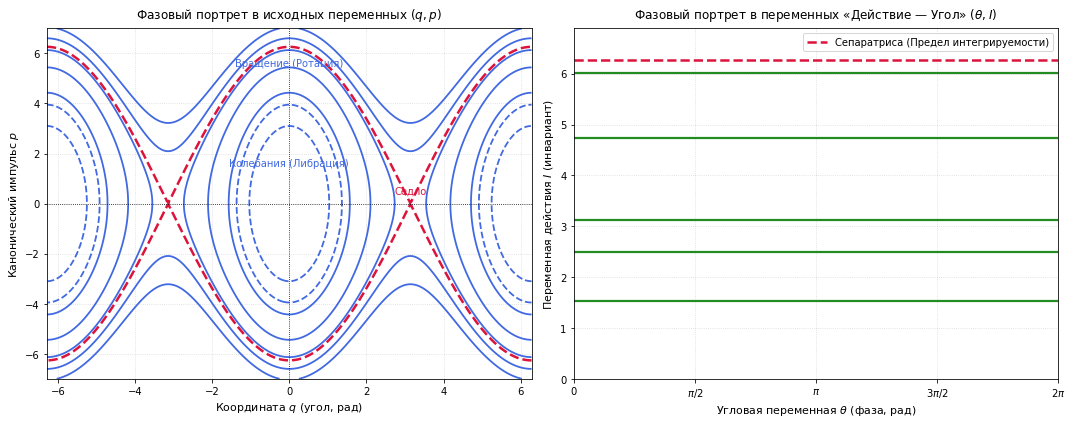

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Задаем физические параметры маятника
m_val, l_val, g_val = 1.0, 1.0, 9.81
omega_0 = np.sqrt(g_val / l_val)

# Энергия сепаратрисы для потенциала V = -mgl*cos(q) равна +mgl (9.81)
# Минимум потенциала (дно ямы) равен -mgl (-9.81)
E_min = -m_val * g_val * l_val
E_sep = m_val * g_val * l_val

# Набор энергий, строго согласованный с потенциалом V = -mgl*cos(q)
# Колебания лежат в диапазоне (-9.81; 9.81)
energies = [-5.0, -2.0, 0.0, 5.0, 9.0, 12.0, 15.0] 

theta_grid = np.linspace(0, 2 * np.pi, 400)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ==========================================
# ПАНЕЛЬ 1: Фазовый портрет в исходных переменных (q, p)
# ==========================================
q_grid = np.linspace(-2 * np.pi, 2 * np.pi, 300)
p_grid = np.linspace(-7.0, 7.0, 300)
Q_mesh, P_mesh = np.meshgrid(q_grid, p_grid)

# Строгое соответствие формуле H из Раздела 1
H_mesh = P_mesh**2 / (2 * m_val * l_val**2) - m_val * g_val * l_val * np.cos(Q_mesh)

# Траектории и точная сепаратриса на уровне E = E_sep
ax1.contour(Q_mesh, P_mesh, H_mesh, levels=energies, colors='royalblue', linewidths=1.8)
ax1.contour(Q_mesh, P_mesh, H_mesh, levels=[E_sep], colors='crimson', linewidths=2.5, linestyles='--')

ax1.set_title("Фазовый портрет в исходных переменных $(q, p)$", fontsize=12, pad=10)
ax1.set_xlabel("Координата $q$ (угол, рад)", fontsize=11)
ax1.set_ylabel("Канонический импульс $p$", fontsize=11)
ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax1.axvline(0, color='black', linewidth=0.8, linestyle=':')
ax1.set_xlim(-2 * np.pi, 2 * np.pi)
ax1.set_ylim(-7.0, 7.0)
ax1.grid(True, linestyle=":", alpha=0.5)

ax1.text(0, 1.5, "Колебания (Либрация)", color="royalblue", fontsize=10, ha="center")
ax1.text(0, 5.5, "Вращение (Ротация)", color="royalblue", fontsize=10, ha="center")
ax1.text(np.pi, 0.4, "Седло", color="crimson", fontsize=10, ha="center")


# ==========================================
# ПАНЕЛЬ 2: Фазовый портрет в переменных «Действие — Угол» (I, theta)
# ==========================================
# Отбираем только колебательные режимы (E < E_sep)
oscillating_energies = [E for E in energies if E < E_sep]

for E in oscillating_energies:
    # Энергия отсчитывается от дна ямы E_min
    I_val = (E - E_min) / omega_0
    ax2.plot(theta_grid, np.full_like(theta_grid, I_val), color="forestgreen", linewidth=2.2)

# Вычисление и точная отрисовка сепаратрисы на правой панели
max_I = (E_sep - E_min) / omega_0
ax2.axhline(max_I, color="crimson", linestyle="--", linewidth=2.5, label="Сепаратриса (Предел интегрируемости)")

ax2.set_title(r"Фазовый портрет в переменных «Действие — Угол» $(\theta, I)$", fontsize=12, pad=10)
ax2.set_xlabel(r"Угловая переменная $\theta$ (фаза, рад)", fontsize=11)
ax2.set_ylabel(r"Переменная действия $I$ (инвариант)", fontsize=11)
ax2.set_xlim(0, 2 * np.pi)
ax2.set_ylim(0, max_I * 1.1)
ax2.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax2.set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
ax2.grid(True, linestyle=":", alpha=0.5)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


### Сравнительный анализ топологии фазовых портретов

Сопоставление левого и правого графиков показывает геометрический смысл канонических преобразований и нормализации гамильтоновых систем:

1. **Сложность исходного пространства (левый график):**
   В физических координатах $(q, p)$ структура движения неоднородна. Мы видим три принципиально разных динамических режима:
   * **Замкнутые эллипсы (либрация):** Маятник совершает колебания около устойчивого центра $(0,0)$. Из-за нелинейности $\sin q$ форма эллипсов искажается по мере роста энергии.
   * **Волнообразные линии (ротация):** При энергиях выше критической маятник совершает полный оборот, импульс никогда не пересекает ноль, а фазовая скорость колеблется.
   * **Сепаратриса (красный пунктир):** Граница, разделяющая колебания и вращение. Движение по ней занимает бесконечное время ($T \to \infty$), стремясь к неустойчивым седловым точкам $\pm\pi$.

2. **Идеальный порядок переменных «действие-угол» (правый график):**
   Правая панель демонстрирует силу асимптотических методов нормализации гамильтоновых систем. Канонический переход Делоне полностью «разгладил» и перестроил топологию пространства:
   * Каждая искаженная колебательная траектория либрации превратилась в **абсолютно ровную горизонтальную прямую**. Переменная действия стала строгим инвариантом ($I = \text{const}$).
   * Сложные ускорения и замедления координаты $q$ превратились в монотонный, равномерный бег угла $\theta$ от $0$ до $2\pi$ с постоянной нелинейной скоростью $\omega(I)$.

#### 📌 Интуиция для теории возмущений
Этот график дает визуальный ответ на вопрос: *«Зачем мы работаем с рядами фон Цейпеля и генераторами Ли?»* 

Цель любого асимптотического метода — взять реальную сложную систему (левый график), учесть нелинейные поправки и принудительно «распрямить» её фазовые кривые в идеальные горизонтальные траектории законов сохранения (правый график). Обладая такой выпрямленной картой, мы можем мгновенно предсказать состояние нелинейной системы на огромное число шагов вперед, не прибегая к пошаговому численному интегрированию.


## 5. Список литературы

Для детального изучения канонического формализма, теории систем «действие-угол» и геометрических основ гамильтоновой механики рекомендуется использовать следующие фундаментальные учебники:

### Раздел А: Гамильтонова и аналитическая механика

1. **Арнольд В. И. «Математические методы классической механики»**
   * *Комментарий:* Глава, посвященная каноническим преобразованиям и переменным «действие-угол», дает геометрическое понимание того, почему переменные Делоне «работают» в многомерных интегрируемых системах.
2. **Ландау Л. Д., Лифшиц Е. М. «Теоретическая физика. Том 1. Механика»**
   * *Комментарий:* Дает лаконичное и физически строгое изложение уравнений Гамильтона-Якоби, канонических преобразований и теории адиабатических инвариантов. Идеален для быстрого освоения физической сути канонического формализма.
3. **Гантмахер Ф. Р. «Лекции по аналитической механике»**
   * *Комментарий:* Один из лучших отечественных университетских учебников. Отличается строгим, но доступным математическим изложением интегральных инвариантов Пуанкаре-Картана, теории канонических преобразований и скобок Пуассона.
4. **Голдстейн Г., Пул Ч., Сафко Дж. «Классическая механика» (Classical Mechanics)**
   * *Комментарий:* Классический университетский курс. Содержит  разоры канонических преобразований с пошаговыми выводами и геометрическими иллюстрациями фазового пространства.

### Раздел Б: Небесная механика и теория возмущений

5. **Маркеев А. П. «Теоретическая механика»**
   * *Комментарий:* Сочетает строгость общей аналитической механики с прикладными задачами небесной динамики (включая устойчивость точек либрации и резонансы).
6. **Дубошин Г. Н. «Небесная механика. Основные задачи и методы»**
   * *Комментарий:* Академический труд для исследователей в области динамической астрономии. Описывает применение канонических уравнений непосредственно к аналитическим методам интегрирования орбит.
7. **Мюррей К., Дермотт С. «Динамика Солнечной системы» (Solar System Dynamics)**
   * *Комментарий:* Известный зарубежный учебник по небесной механике. Главы 2 и 3 детально, на конкретных примерах, объясняют разложение возмущающей функции в переменных Делоне и Пуанкаре.
